# 00 - Preprocesamiento de radiografías

**Proyecto:** Detección automática de fracturas óseas en radiografías  
**Materia:** Visión por Computadora II - CEIA/FIUBA  
**Autores:** Lucia T. Capon Paul · César Andrés Orellana · Leandro Britez

En este notebook preparamos una copia del dataset para entrenar los modelos. Aplicamos normalización robusta, CLAHE y un *unsharp masking* suave. Elegimos estas técnicas porque buscamos mejorar el contraste de las estructuras óseas sin cambiar las cajas anotadas ni inventar detalles en la radiografía.

### ¿Por qué aplicamos estas técnicas?

Las radiografías pueden venir con distintos niveles de brillo y contraste según el equipo, la posición del paciente o la exportación de la imagen. Esto es un problema porque una fractura puede aparecer como una línea muy fina y con poco contraste respecto del hueso. Por eso aplicamos tres pasos moderados:

- **Normalización robusta por percentiles:** descartamos los valores de intensidad más extremos (percentiles 1 y 99) y reescalamos el resto. De esta forma evitamos que unos pocos píxeles demasiado oscuros o claros dominen la imagen. Nos ayuda a que las radiografías tengan un rango de intensidades más comparable entre sí.
- **CLAHE moderado:** mejora el contraste en zonas pequeñas de la imagen, no solamente en toda la radiografía. Esto puede hacer más visibles detalles locales del hueso. Elegimos un valor moderado para no aumentar demasiado el ruido ni los artefactos.
- **Unsharp masking suave:** refuerza bordes usando la diferencia entre la imagen y una versión suavizada. Lo usamos con una intensidad baja porque queremos resaltar transiciones sutiles, pero no crear bordes artificiales que puedan confundir al modelo.

No usamos filtros fuertes, super-resolución ni detección de bordes como entrada. Nuestro objetivo no es modificar la información clínica de la radiografía, sino hacer que la información original sea más fácil de aprovechar para el modelo.

### Relación con el paper guía

Tomamos como antecedente el trabajo de Srinivasu *et al.* (2025), *Exploring the impact of hyperparameter and data augmentation in YOLO V10 for accurate bone fracture detection from X-ray images*. En ese paper los autores estudian la detección de fracturas en radiografías y aplican **CLAHE** y **unsharp masking** antes de entrenar YOLOv10. Reportan una mejora moderada al combinar ambas técnicas respecto de utilizar imágenes sin ese procesamiento.

No copiamos el método de forma automática. Lo adaptamos a nuestro proyecto de la siguiente manera:

- Agregamos **normalización robusta por percentiles** antes de CLAHE. El paper se centra en contraste y afilado; nosotros incorporamos este paso para reducir diferencias extremas de exposición entre radiografías.
- Usamos parámetros **conservadores y explícitos** (`clipLimit=2.0` y afilado `amount=0.4`) para evitar que el realce aumente demasiado el ruido.
- Aplicamos el mismo preprocesamiento determinista sobre train, valid y test, y dejamos los aumentos aleatorios sólo para train. Así la evaluación representa el mismo flujo que usaríamos en inferencia.
- Evaluaremos el aporte real de este pipeline contra un baseline sin preprocesamiento y no asumiremos que los resultados del paper se repiten en nuestro dataset, modelos o configuración.

La referencia completa del antecedente está disponible en `Paper_guia.pdf` y en `paper_guia.md` dentro del repositorio.

> Importante: este preprocesamiento es determinista. Por eso lo aplicamos de la misma manera a train, valid y test. Las técnicas aleatorias de *data augmentation* se mantienen solamente durante el entrenamiento.

## 1. Importar las librerías

En este paso importamos las librerías necesarias para leer las imágenes, aplicar las transformaciones, visualizar una muestra y copiar las anotaciones YOLO sin modificarlas.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.preprocessing import (
    PreprocessingConfig,
    create_preprocessed_dataset,
    preprocess_xray,
)


## 2. Definir las rutas de entrada y salida

Usamos el dataset original solamente como entrada. El resultado se guarda en una carpeta nueva para no alterar los archivos descargados ni las anotaciones originales. Si la carpeta de salida ya existe, el notebook se detiene para evitar sobrescribir un experimento anterior por accidente.

In [2]:
DATA_ROOT = Path('../data/bone-fracture-detection-4')
OUTPUT_ROOT = Path('../data/bone-fracture-detection-4-preprocessed')
SPLITS = ('train', 'valid', 'test')

assert DATA_ROOT.exists(), f'No se encontró el dataset en: {DATA_ROOT.resolve()}'
assert not OUTPUT_ROOT.exists(), (
    f'La salida ya existe en: {OUTPUT_ROOT.resolve()}. '
    'Elegir otra carpeta o revisar el experimento anterior antes de ejecutarlo de nuevo.'
)

print(f'Dataset original: {DATA_ROOT.resolve()}')
print(f'Dataset preprocesado: {OUTPUT_ROOT.resolve()}')

Dataset original: /Users/cesar/Documents/Especializacion/Cuarto Bimestre/Vision por Computadora II/VPCII_TP_CEIA/data/bone-fracture-detection-4
Dataset preprocesado: /Users/cesar/Documents/Especializacion/Cuarto Bimestre/Vision por Computadora II/VPCII_TP_CEIA/data/bone-fracture-detection-4-preprocessed


## 3. Fijar los parámetros del preprocesamiento

Primero recortamos intensidades muy extremas usando los percentiles 1 y 99, y después reescalamos la imagen. Luego usamos CLAHE para recuperar contraste local. Finalmente aplicamos un afilado suave: la idea es resaltar bordes, pero sin exagerarlos ni amplificar demasiado el ruido. Estos valores se dejan visibles para poder documentarlos y ajustarlos en una ablación posterior.

Elegimos parámetros conservadores: `clipLimit=2.0` para CLAHE y `amount=0.4` para el afilado. Si estos valores fueran muy altos, podríamos amplificar ruido, texto o marcas de la radiografía.

In [3]:
PREPROCESSING_CONFIG = PreprocessingConfig(
    low_percentile=1,
    high_percentile=99,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    unsharp_sigma=1.2,
    unsharp_amount=0.4,
    jpeg_quality=95,
)

print('Parámetros configurados correctamente.')

Parámetros configurados correctamente.


## 4. Usar la función reutilizable de preprocesamiento

La lógica del preprocesamiento está implementada en `src/preprocessing.py`. Así podemos reutilizar exactamente la misma función en otros notebooks o scripts, sin duplicar código. La salida tiene tres canales iguales para que los modelos preentrenados que esperan imágenes RGB puedan recibirla sin modificar su arquitectura.

## 5. Visualizar una radiografía antes y después

Antes de procesar todo el dataset, comparamos una imagen de entrenamiento. Esta revisión visual nos permite detectar parámetros demasiado agresivos: por ejemplo, ruido muy marcado, regiones saturadas o bordes artificiales.

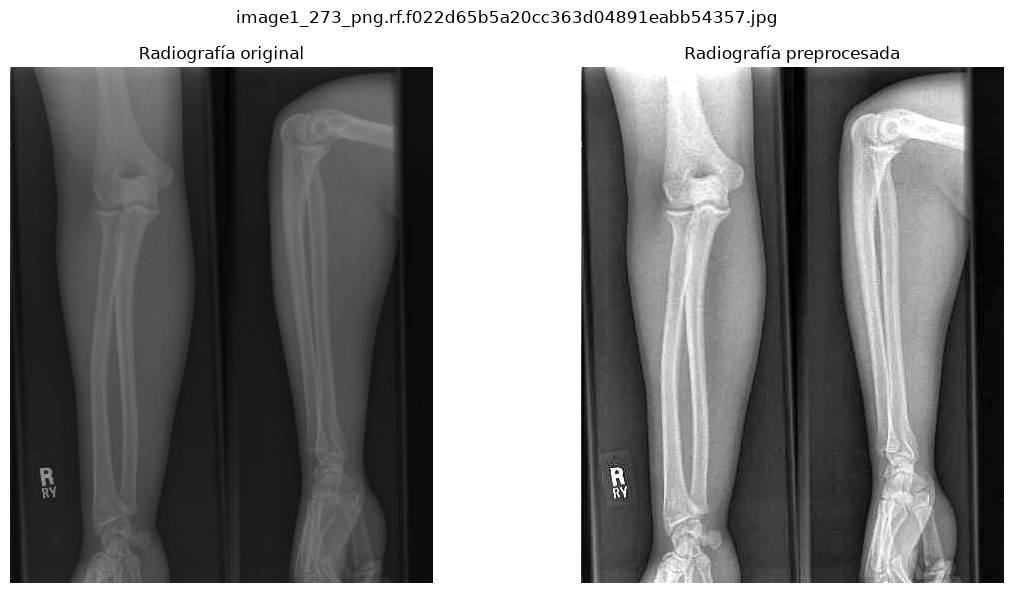

In [4]:
sample_path = next((DATA_ROOT / 'train' / 'images').glob('*.jpg'))
sample_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
assert sample_bgr is not None, f'No se pudo leer: {sample_path}'
sample_processed = preprocess_xray(sample_bgr, PREPROCESSING_CONFIG)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB), cmap='gray')
axes[0].set_title('Radiografía original')
axes[1].imshow(cv2.cvtColor(sample_processed, cv2.COLOR_BGR2RGB), cmap='gray')
axes[1].set_title('Radiografía preprocesada')

for ax in axes:
    ax.axis('off')

plt.suptitle(sample_path.name)
plt.tight_layout()
plt.show()

## 6. Crear el nuevo dataset preprocesado

Ahora generamos la estructura esperada por Ultralytics y procesamos todas las imágenes. Las etiquetas se copian exactamente como están porque el preprocesamiento no rota, no recorta ni redimensiona. Por esta razón las *bounding boxes* continúan siendo válidas. No aplicamos augmentations aleatorias aquí; esas transformaciones corresponden solamente al entrenamiento.

In [5]:
summary = create_preprocessed_dataset(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    config=PREPROCESSING_CONFIG,
    splits=SPLITS,
)
summary


Procesando train:   0%|          | 0/3631 [00:00<?, ?it/s]

Procesando valid:   0%|          | 0/348 [00:00<?, ?it/s]

Procesando test:   0%|          | 0/169 [00:00<?, ?it/s]

[{'split': 'train', 'imagenes_procesadas': 3631, 'archivos_etiquetas': 3631},
 {'split': 'valid', 'imagenes_procesadas': 348, 'archivos_etiquetas': 348},
 {'split': 'test', 'imagenes_procesadas': 169, 'archivos_etiquetas': 169}]

## 7. Verificar que el resultado sea consistente

Finalmente verificamos que la cantidad de imágenes y etiquetas sea la misma que en el dataset original, y comprobamos que una imagen procesada pueda volver a leerse. Esta validación rápida evita continuar al entrenamiento con una exportación incompleta.

In [6]:
for row in summary:
    split = row['split']
    original_images = len(list((DATA_ROOT / split / 'images').glob('*.jpg')))
    output_images = len(list((OUTPUT_ROOT / split / 'images').glob('*.jpg')))
    original_labels = len(list((DATA_ROOT / split / 'labels').glob('*.txt')))
    output_labels = len(list((OUTPUT_ROOT / split / 'labels').glob('*.txt')))

    assert original_images == output_images, f'Cantidad de imágenes distinta en {split}'
    assert original_labels == output_labels, f'Cantidad de etiquetas distinta en {split}'

    check_image = next((OUTPUT_ROOT / split / 'images').glob('*.jpg'))
    assert cv2.imread(str(check_image), cv2.IMREAD_COLOR) is not None, (
        f'No se pudo volver a leer: {check_image}'
    )

summary

[{'split': 'train', 'imagenes_procesadas': 3631, 'archivos_etiquetas': 3631},
 {'split': 'valid', 'imagenes_procesadas': 348, 'archivos_etiquetas': 348},
 {'split': 'test', 'imagenes_procesadas': 169, 'archivos_etiquetas': 169}]

## 8. Próximo paso

El dataset preprocesado queda disponible en `../data/bone-fracture-detection-4-preprocessed/data.yaml`. Para entrenar con esta versión, en los notebooks de entrenamiento debemos asignar esa ruta a `DATA_YAML`. Mantendremos exactamente las mismas particiones y anotaciones para que la comparación contra el baseline sea justa.